In [31]:
# SETUP

from google.colab import drive
drive.mount("/content/drive")

import json
import joblib
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

SEED = 42
np.random.seed(SEED)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
# PROJECT PATHS

PROJECT_ROOT = Path(
    "/content/drive/MyDrive/intentmap-nids/intentmap-nids"
)

DATA_DIR = PROJECT_ROOT / "data" / "processed"
MODEL_DIR = PROJECT_ROOT / "models"
REPORT_DIR = PROJECT_ROOT / "reports"
CONFIG_DIR = PROJECT_ROOT / "config"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
CONFIG_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)

Project root: /content/drive/MyDrive/intentmap-nids/intentmap-nids
Data directory: /content/drive/MyDrive/intentmap-nids/intentmap-nids/data/processed


In [33]:
# LOAD TRAIN / VALIDATION / TEST DATA

def load_npz(path):
    data = np.load(path)
    X = data["X"]
    y = data["y"] if "y" in data.files else None
    return X, y


X_train, _ = load_npz(DATA_DIR / "train_normal.npz")
X_val, _ = load_npz(DATA_DIR / "val_normal.npz")
X_test, y_test = load_npz(DATA_DIR / "test_full.npz")

X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)

print("Normal training data:", X_train.shape)
print("Normal validation data:", X_val.shape)
print("Full testing data:", X_test.shape)

print("Normal test records:", (y_test == 0).sum())
print("Attack test records:", (y_test == 1).sum())

Normal training data: (41065, 41)
Normal validation data: (10266, 41)
Full testing data: (82332, 41)
Normal test records: 37000
Attack test records: 45332


In [34]:
# VERIFY INPUT DIMENSIONS AND DATA QUALITY

assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1], \
    "Feature dimensions do not match."

assert not np.isnan(X_train).any(), "Training data contains NaN values."
assert not np.isinf(X_train).any(), "Training data contains infinity."

print("Input features:", X_train.shape[1])
print("Training minimum:", np.min(X_train))
print("Training maximum:", np.max(X_train))
print("Training mean:", np.mean(X_train))
print("Training std:", np.std(X_train))
print("Any NaN:", np.isnan(X_train).any())
print("Any infinity:", np.isinf(X_train).any())

Input features: 41
Training minimum: -3.3884416
Training maximum: 7.9811873
Training mean: 0.08408545
Training std: 0.5488584
Any NaN: False
Any infinity: False


In [35]:
# CREATE ISOLATION FOREST MODEL

isolation_forest_model = IsolationForest(
    n_estimators=300,
    max_samples=0.8,
    max_features=1.0,
    contamination="auto",
    random_state=SEED,
    n_jobs=-1
)

print("Isolation Forest model created.")
print(isolation_forest_model)

Isolation Forest model created.
IsolationForest(max_samples=0.8, n_estimators=300, n_jobs=-1, random_state=42)


In [36]:
# TRAIN ON NORMAL DATA ONLY

print("Starting Isolation Forest training...")

isolation_forest_model.fit(X_train)

print("Isolation Forest training completed.")
print("Training records:", X_train.shape[0])
print("Input features:", X_train.shape[1])

Starting Isolation Forest training...
Isolation Forest training completed.
Training records: 41065
Input features: 41


In [37]:
# CREATE ISOLATION FOREST ANOMALY SCORES

# sklearn gives lower scores to more abnormal records.
# Reverse the sign so higher score means more anomalous.

def isolation_forest_anomaly_scores(model, X):
    return -model.score_samples(X)


train_scores = isolation_forest_anomaly_scores(
    isolation_forest_model, X_train
)

val_scores = isolation_forest_anomaly_scores(
    isolation_forest_model, X_val
)

test_scores = isolation_forest_anomaly_scores(
    isolation_forest_model, X_test
)

print("Training scores:")
print("Mean:", train_scores.mean(), "Std:", train_scores.std())

print("\nValidation scores:")
print("Mean:", val_scores.mean(), "Std:", val_scores.std())

print("\nTest scores:")
print("Mean:", test_scores.mean(), "Std:", test_scores.std())

print("\nHigher Isolation Forest score = more anomalous.")

Training scores:
Mean: 0.4008790734626264 Std: 0.041450637968681425

Validation scores:
Mean: 0.4010166093607668 Std: 0.04108581208393697

Test scores:
Mean: 0.5007722928306387 Std: 0.12134012203413763

Higher Isolation Forest score = more anomalous.


In [38]:
# CALIBRATE FALSE-POSITIVE BUDGET THRESHOLDS

fp_budgets = {
    "0.5% budget": 0.005,
    "1% budget": 0.01,
    "3% budget": 0.03
}

thresholds = {}

for label, budget in fp_budgets.items():
    threshold = np.quantile(val_scores, 1 - budget)
    thresholds[label] = threshold

    val_predictions = (val_scores >= threshold).astype(int)
    validation_fpr = val_predictions.mean()

    print(
        f"{label}: "
        f"threshold={threshold:.8f}, "
        f"validation anomaly rate={validation_fpr:.4%}"
    )

0.5% budget: threshold=0.56764957, validation anomaly rate=0.5065%
1% budget: threshold=0.54605377, validation anomaly rate=1.0033%
3% budget: threshold=0.49663910, validation anomaly rate=3.0002%


In [39]:
# EVALUATION FUNCTION

def evaluate_threshold(y_true, scores, threshold):
    predictions = (scores >= threshold).astype(int)

    precision = precision_score(
        y_true, predictions, zero_division=0
    )

    recall = recall_score(
        y_true, predictions, zero_division=0
    )

    f1 = f1_score(
        y_true, predictions, zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    actual_fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    return {
        "Threshold": float(threshold),
        "Precision": float(precision),
        "Recall": float(recall),
        "F1": float(f1),
        "Actual FPR": float(actual_fpr),
        "False alerts per 1000": float(actual_fpr * 1000),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }

In [40]:
# EVALUATE ALL FALSE-POSITIVE BUDGETS

evaluation_rows = []

for label, threshold in thresholds.items():
    metrics = evaluate_threshold(
        y_test,
        test_scores,
        threshold
    )

    metrics["Budget"] = label
    evaluation_rows.append(metrics)


isolation_forest_budget_results = pd.DataFrame(
    evaluation_rows
)

isolation_forest_budget_results = isolation_forest_budget_results[
    [
        "Budget",
        "Threshold",
        "Precision",
        "Recall",
        "F1",
        "Actual FPR",
        "False alerts per 1000",
        "TN",
        "FP",
        "FN",
        "TP"
    ]
]

display(isolation_forest_budget_results)

,Budget,Threshold,Precision,Recall,F1,Actual FPR,False alerts per 1000,TN,FP,FN,TP
0,0.5% budget,0.567650,0.949434,0.608863,0.741932,0.039730,39.729730,35530,1470,17731,27601
1,1% budget,0.546054,0.940079,0.617070,0.745072,0.048189,48.189189,35217,1783,17359,27973
2,3% budget,0.496639,0.905033,0.663681,0.765791,0.085324,85.324324,33843,3157,15246,30086


In [41]:
# ROC-AUC AND PR-AUC

if_roc_auc = roc_auc_score(
    y_test,
    test_scores
)

if_pr_auc = average_precision_score(
    y_test,
    test_scores
)

print(f"Isolation Forest ROC-AUC: {if_roc_auc:.4f}")
print(f"Isolation Forest PR-AUC: {if_pr_auc:.4f}")

Isolation Forest ROC-AUC: 0.8510
Isolation Forest PR-AUC: 0.8974


In [42]:
# SAVE BUDGET RESULTS

IF_BUDGET_FILE = (
    REPORT_DIR / "isolation_forest_budget_results.csv"
)

isolation_forest_budget_results.to_csv(
    IF_BUDGET_FILE,
    index=False
)

print("Saved:", IF_BUDGET_FILE)

Saved: /content/drive/MyDrive/intentmap-nids/intentmap-nids/reports/isolation_forest_budget_results.csv


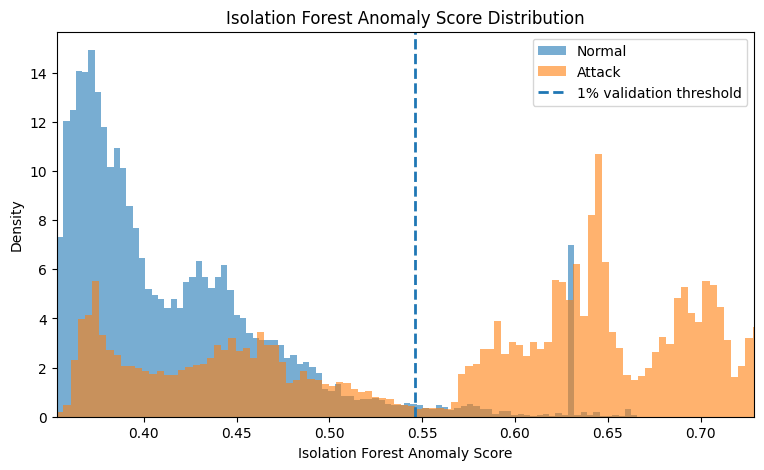

Saved: /content/drive/MyDrive/intentmap-nids/intentmap-nids/reports/isolation_forest_scores.png


In [43]:
# PLOT NORMAL VS ATTACK SCORES

normal_scores = test_scores[y_test == 0]
attack_scores = test_scores[y_test == 1]

plt.figure(figsize=(9, 5))

plt.hist(
    normal_scores,
    bins=100,
    alpha=0.6,
    density=True,
    label="Normal"
)

plt.hist(
    attack_scores,
    bins=100,
    alpha=0.6,
    density=True,
    label="Attack"
)

plt.axvline(
    thresholds["1% budget"],
    linestyle="--",
    linewidth=2,
    label="1% validation threshold"
)

plt.xlabel("Isolation Forest Anomaly Score")
plt.ylabel("Density")
plt.title("Isolation Forest Anomaly Score Distribution")
plt.legend()

plt.xlim(
    np.percentile(test_scores, 0.1),
    np.percentile(test_scores, 99)
)

IF_SCORE_PLOT = (
    REPORT_DIR / "isolation_forest_scores.png"
)

plt.savefig(
    IF_SCORE_PLOT,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", IF_SCORE_PLOT)

In [44]:
# CREATE DASHBOARD PREDICTIONS

threshold_005 = thresholds["0.5% budget"]
threshold_01 = thresholds["1% budget"]
threshold_03 = thresholds["3% budget"]

if_pred_005 = (test_scores >= threshold_005).astype(int)
if_pred_01 = (test_scores >= threshold_01).astype(int)
if_pred_03 = (test_scores >= threshold_03).astype(int)

In [45]:
# CREATE DASHBOARD-READY DATAFRAME

isolation_forest_dashboard_results = pd.DataFrame({
    "record_id": range(1, len(test_scores) + 1),
    "actual_label": y_test,
    "actual_class": [
        "Attack" if y == 1 else "Normal"
        for y in y_test
    ],
    "if_score": test_scores,
    "if_prediction_0.5pct": if_pred_005,
    "if_prediction_1pct": if_pred_01,
    "if_prediction_3pct": if_pred_03,
    "if_status_0.5pct": [
        "Anomaly" if p == 1 else "Normal"
        for p in if_pred_005
    ],
    "if_status_1pct": [
        "Anomaly" if p == 1 else "Normal"
        for p in if_pred_01
    ],
    "if_status_3pct": [
        "Anomaly" if p == 1 else "Normal"
        for p in if_pred_03
    ]
})

# 1% budget is the default dashboard operating point
isolation_forest_dashboard_results["default_threshold"] = threshold_01
isolation_forest_dashboard_results["default_prediction"] = if_pred_01

isolation_forest_dashboard_results["default_status"] = [
    "Anomaly" if p == 1 else "Normal"
    for p in if_pred_01
]

isolation_forest_dashboard_results["correct_prediction"] = (
    isolation_forest_dashboard_results["default_prediction"]
    == isolation_forest_dashboard_results["actual_label"]
)

display(isolation_forest_dashboard_results.head(10))

,record_id,actual_label,actual_class,if_score,if_prediction_0.5pct,if_prediction_1pct,if_prediction_3pct,if_status_0.5pct,if_status_1pct,if_status_3pct,default_threshold,default_prediction,default_status,correct_prediction
0,1,0,Normal,0.450713,0,0,0,Normal,Normal,Normal,0.546054,0,Normal,True
1,2,0,Normal,0.463685,0,0,0,Normal,Normal,Normal,0.546054,0,Normal,True
2,3,0,Normal,0.439728,0,0,0,Normal,Normal,Normal,0.546054,0,Normal,True
3,4,0,Normal,0.441019,0,0,0,Normal,Normal,Normal,0.546054,0,Normal,True
4,5,0,Normal,0.460208,0,0,0,Normal,Normal,Normal,0.546054,0,Normal,True
5,6,0,Normal,0.464486,0,0,0,Normal,Normal,Normal,0.546054,0,Normal,True
6,7,0,Normal,0.473945,0,0,0,Normal,Normal,Normal,0.546054,0,Normal,True
7,8,0,Normal,0.482098,0,0,0,Normal,Normal,Normal,0.546054,0,Normal,True
8,9,0,Normal,0.630057,1,1,1,Anomaly,Anomaly,Anomaly,0.546054,1,Anomaly,False
9,10,0,Normal,0.630057,1,1,1,Anomaly,Anomaly,Anomaly,0.546054,1,Anomaly,False


In [46]:
# SAVE DASHBOARD CSV

IF_DASHBOARD_FILE = (
    REPORT_DIR / "isolation_forest_dashboard_results.csv"
)

isolation_forest_dashboard_results.to_csv(
    IF_DASHBOARD_FILE,
    index=False
)

print("Isolation Forest dashboard results saved:")
print(IF_DASHBOARD_FILE)
print("Shape:", isolation_forest_dashboard_results.shape)

Isolation Forest dashboard results saved:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/reports/isolation_forest_dashboard_results.csv
Shape: (82332, 14)


In [47]:
# SAVE ISOLATION FOREST MODEL

IF_MODEL_FILE = (
    MODEL_DIR / "isolation_forest_candidate1.joblib"
)

joblib.dump(
    isolation_forest_model,
    IF_MODEL_FILE
)

print("Saved Isolation Forest model:")
print(IF_MODEL_FILE)

Saved Isolation Forest model:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/models/isolation_forest_candidate1.joblib


In [48]:
# SAVE ISOLATION FOREST CONFIGURATION

IF_CONFIG_FILE = (
    CONFIG_DIR / "isolation_forest_candidate1.json"
)

if_information = {
    "model": "Isolation Forest",
    "model_type": "Unsupervised comparison model",
    "purpose": "Network anomaly detection",
    "training_data": "train_normal.npz",
    "validation_data": "val_normal.npz",
    "test_data": "test_full.npz",
    "training_strategy": "Normal-only training",
    "input_features": int(X_train.shape[1]),
    "n_estimators": 300,
    "max_samples": 0.8,
    "max_features": 1.0,
    "contamination": "auto",
    "random_seed": SEED,
    "score_direction": "Higher score means more anomalous",
    "score_definition": "negative of sklearn IsolationForest score_samples",
    "roc_auc": float(if_roc_auc),
    "pr_auc": float(if_pr_auc),
    "thresholds": {
        label: float(value)
        for label, value in thresholds.items()
    }
}

with open(IF_CONFIG_FILE, "w") as f:
    json.dump(if_information, f, indent=4)

print("Saved configuration:")
print(IF_CONFIG_FILE)

Saved configuration:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/config/isolation_forest_candidate1.json


In [49]:
# VERIFY OUTPUT FILES

files_to_check = [
    IF_MODEL_FILE,
    IF_CONFIG_FILE,
    IF_BUDGET_FILE,
    IF_DASHBOARD_FILE,
    IF_SCORE_PLOT
]

print("\nIsolation Forest implementation completed.")

for file in files_to_check:
    print(file.name, "->", file.exists())

print("\nFiles created:")
print("1. isolation_forest_candidate1.joblib")
print("2. isolation_forest_candidate1.json")
print("3. isolation_forest_budget_results.csv")
print("4. isolation_forest_dashboard_results.csv")
print("5. isolation_forest_scores.png")


Isolation Forest implementation completed.
isolation_forest_candidate1.joblib -> True
isolation_forest_candidate1.json -> True
isolation_forest_budget_results.csv -> True
isolation_forest_dashboard_results.csv -> True
isolation_forest_scores.png -> True

Files created:
1. isolation_forest_candidate1.joblib
2. isolation_forest_candidate1.json
3. isolation_forest_budget_results.csv
4. isolation_forest_dashboard_results.csv
5. isolation_forest_scores.png


In [50]:
# CREATE ISOLATION FOREST ZIP PACKAGE

from google.colab import files

IF_ZIP_FILE = "/content/Isolation_Forest_Results.zip"

files_to_zip = [
    IF_MODEL_FILE,
    IF_CONFIG_FILE,
    IF_BUDGET_FILE,
    IF_DASHBOARD_FILE,
    IF_SCORE_PLOT
]

with zipfile.ZipFile(
    IF_ZIP_FILE,
    "w",
    zipfile.ZIP_DEFLATED
) as zipf:

    for file_path in files_to_zip:
        if file_path.exists():
            zipf.write(
                file_path,
                arcname=file_path.name
            )
            print("Added:", file_path.name)
        else:
            print("Missing:", file_path)

print("\nIsolation Forest package created:")
print(IF_ZIP_FILE)

files.download(IF_ZIP_FILE)

Added: isolation_forest_candidate1.joblib
Added: isolation_forest_candidate1.json
Added: isolation_forest_budget_results.csv
Added: isolation_forest_dashboard_results.csv
Added: isolation_forest_scores.png

Isolation Forest package created:
/content/Isolation_Forest_Results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>